# 01 — Data Understanding (HUPA-UCM)

**SKILL.md Step 1.** This notebook produces the verifiable evidence base for §3 of `reports/report.md` (Dataset Description). It does *not* perform statistical EDA — that is Step 2 (`02_eda.ipynb`).

**Goals:**
1. Confirm the on-disk schema and record counts.
2. Produce a per-patient summary table (rows, duration, glucose stats, censoring rate, modality coverage, demographics).
3. Save the summary as `data/interim/hupa_cohort_summary.csv` for downstream use.
4. Print a textual summary suitable for direct quotation in §3 of `report.md`.

**Reproducibility:** every number printed below is derived by the cells in this notebook — no hand-typed values.

## Cell 0 — Colab detection and BASE_PATH

In [1]:
import os
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/glucose-thesis/'
except ImportError:
    IN_COLAB = False
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'IN_COLAB={IN_COLAB}')
print(f'BASE_PATH={BASE_PATH}')

IN_COLAB=False
BASE_PATH=E:\claude-co-work


## Cell 1 — Install / import dependencies

In [2]:
# Uncomment in Colab:
# !pip install -q pandas numpy matplotlib openpyxl

import sys
sys.path.insert(0, os.path.join(BASE_PATH, 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_loading import (
    list_hupa_participants,
    load_hupa_patient,
    load_patient_characteristics,
    summarise_cohort,
)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

## Cell 2 — Confirm participant list and schema

The released HUPA-UCM cohort has 25 patients with the IDs below. The schema is identical across all patient files, with 8 time-step columns plus an injected `participant_id`.

In [3]:
pids = list_hupa_participants(BASE_PATH)
print(f'Number of participants: {len(pids)}')
print(f'IDs: {pids}')

sample = load_hupa_patient(pids[0], BASE_PATH)
print(f'\nSchema (from {pids[0]}):')
print(sample.dtypes)
print(f'\nFirst 3 rows:')
print(sample.head(3))

Number of participants: 25
IDs: ['HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P', 'HUPA0006P', 'HUPA0007P', 'HUPA0009P', 'HUPA0010P', 'HUPA0011P', 'HUPA0014P', 'HUPA0015P', 'HUPA0016P', 'HUPA0017P', 'HUPA0018P', 'HUPA0019P', 'HUPA0020P', 'HUPA0021P', 'HUPA0022P', 'HUPA0023P', 'HUPA0024P', 'HUPA0025P', 'HUPA0026P', 'HUPA0027P', 'HUPA0028P']

Schema (from HUPA0001P):
participant_id                    object
time                      datetime64[ns]
glucose                          float64
calories                         float64
heart_rate                       float64
steps                              int64
basal_rate                       float64
bolus_volume_delivered           float64
carb_input                       float64
dtype: object

First 3 rows:
  participant_id                time  glucose  calories  heart_rate  steps  basal_rate  bolus_volume_delivered  carb_input
0      HUPA0001P 2018-06-13 18:40:00    332.0    6.3595   82.322835     34    0.091667         

## Cell 3 — Static metadata (clinical demographics)

Loaded from `data/data_hupa/patient_data_characteristic.xlsx`. All 25 patients have complete records for HbA1c, age, gender, weight, height, DX time, and treatment (CSII vs MDI).

In [4]:
static = load_patient_characteristics(BASE_PATH)
print(f'Static metadata shape: {static.shape}')
print(f'\nFull table:')
print(static.to_string(index=False))

print('\nCohort-level summary:')
print(f'  Female / Male: {(static["gender"]=="Female").sum()} / {(static["gender"]=="Male").sum()}')
print(f'  Treatment CSII / MDI: {(static["treatment"]=="CSII").sum()} / {(static["treatment"]=="MDI").sum()}')
print(f'  HbA1c [%]: mean={static["hba1c_pct"].mean():.2f}, sd={static["hba1c_pct"].std():.2f}, range={static["hba1c_pct"].min():.1f}-{static["hba1c_pct"].max():.1f}')
print(f'  Age [y]:    mean={static["age_years"].mean():.2f}, sd={static["age_years"].std():.2f}, range={static["age_years"].min():.1f}-{static["age_years"].max():.1f}')
print(f'  DX time [y]: mean={static["dx_time_years"].mean():.2f}, sd={static["dx_time_years"].std():.2f}, range={static["dx_time_years"].min():.1f}-{static["dx_time_years"].max():.1f}')
print(f'  BMI [kg/m^2]: mean={static["bmi"].mean():.2f}, sd={static["bmi"].std():.2f}, range={static["bmi"].min():.2f}-{static["bmi"].max():.2f}')

Static metadata shape: (25, 9)

Full table:
participant_id gender  hba1c_pct  age_years  dx_time_years  weight_kg  height_cm treatment       bmi
     HUPA0001P Female        8.2       56.3           15.5       59.0        161      CSII 22.761468
     HUPA0002P   Male        7.1       48.6           36.5       82.4        186      CSII 23.817782
     HUPA0003P   Male        7.3       43.4           12.5       62.0        182      CSII 18.717546
     HUPA0004P   Male        7.8       41.2            8.5       88.0        180      CSII 27.160494
     HUPA0005P Female        6.9       41.9           39.5       58.5        161      CSII 22.568574
     HUPA0006P   Male        7.8       22.1           13.5       71.0        170      CSII 24.567474
     HUPA0007P   Male        6.6       37.6           10.1      102.6        183      CSII 30.636926
     HUPA0009P Female        7.6       41.2           30.7       64.0        165      CSII 23.507805
     HUPA0010P Female        6.0       41.9    

## Cell 4 — Per-patient cohort summary

The summary table joins clinical static metadata with derived per-patient statistics (record count, duration, glycaemic-zone proportions, sensor-cap rates, modality recording coverage). Each row is one patient.

In [5]:
summary = summarise_cohort(BASE_PATH)
print(f'Summary shape: {summary.shape}')
print(summary.to_string(index=False))

Summary shape: (25, 21)
participant_id  n_rows  days          time_start            time_end  glucose_mean  glucose_std  glucose_min  glucose_max  pct_hypo  pct_in_range  pct_hyper  pct_glucose_low_cap  pct_glucose_high_extreme  basal_recording_pct  bolus_events  carb_events  hba1c_pct  age_years treatment       bmi
     HUPA0001P    4096  14.2 2018-06-13 18:40:00 2018-06-27 23:55:00    181.443726    70.644633         40.0        444.0  1.440430     56.494141  42.065430             0.146484                  0.195312            93.041992            76           40        8.2       56.3      CSII 22.761468
     HUPA0002P    3181  11.0 2018-06-13 22:45:00 2018-06-24 23:45:00    113.469664    59.145068         40.0        310.0 23.860421     61.490097  14.649481             5.815781                  0.000000            99.622760            51           12        7.1       48.6      CSII 23.817782
     HUPA0003P    3770  13.1 2018-06-13 21:40:00 2018-06-26 23:45:00    143.273519    61.32654

## Cell 5 — Save summary to disk

Persist for downstream notebooks (02_eda, 03_preprocessing) and direct citation in the report.

In [6]:
interim_dir = os.path.join(BASE_PATH, 'data', 'interim')
os.makedirs(interim_dir, exist_ok=True)
out_csv = os.path.join(interim_dir, 'hupa_cohort_summary.csv')
summary.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

Saved: E:\claude-co-work\data\interim\hupa_cohort_summary.csv


## Cell 6 — Headline cohort statistics

These numbers are reproduced verbatim in §3 of `reports/report.md`.

In [7]:
n_patients = len(summary)
total_rows = summary['n_rows'].sum()
total_days = summary['days'].sum()

print('=== Headline cohort statistics ===')
print(f'Number of patients:      {n_patients}')
print(f'Total 5-min records:     {total_rows:,}')
print(f'Total patient-days:      {total_days:.1f}')
print(f'Median duration (days):  {summary["days"].median():.1f}')
print(f'Shortest patient (days): {summary["days"].min():.1f}  ({summary.loc[summary["days"].idxmin(),"participant_id"]})')
print(f'Longest patient (days):  {summary["days"].max():.1f}  ({summary.loc[summary["days"].idxmax(),"participant_id"]})')

print('\n=== Duration imbalance (key concern for split strategy) ===')
top3 = summary.nlargest(3, 'n_rows')[['participant_id','n_rows','days']]
for _, r in top3.iterrows():
    print(f'  {r["participant_id"]}: {r["n_rows"]:,} rows = {100*r["n_rows"]/total_rows:.2f}% of dataset, {r["days"]} days')
print(f'  Top 3 combined:        {100*top3["n_rows"].sum()/total_rows:.2f}% of dataset')

print('\n=== Glycaemic distribution (cohort-weighted average) ===')
print(f'Hypoglycaemia (<70 mg/dL):  {summary["pct_hypo"].mean():.2f}%')
print(f'In range (70-180 mg/dL):    {summary["pct_in_range"].mean():.2f}%')
print(f'Hyperglycaemia (>180):      {summary["pct_hyper"].mean():.2f}%')
print(f'Sensor low cap (==40):      {summary["pct_glucose_low_cap"].mean():.3f}%  (max in HUPA0002 etc.)')
print(f'Sensor high extreme (>400): {summary["pct_glucose_high_extreme"].mean():.3f}%')

print('\n=== Modality recording coverage ===')
no_basal = summary[summary['basal_recording_pct']==0]['participant_id'].tolist()
no_bolus = summary[summary['bolus_events']==0]['participant_id'].tolist()
no_carb  = summary[summary['carb_events']==0]['participant_id'].tolist()
print(f'Patients with NO basal record:  {no_basal}')
print(f'Patients with NO bolus events:  {no_bolus}')
print(f'Patients with NO carb events:   {no_carb}')

=== Headline cohort statistics ===
Number of patients:      25
Total 5-min records:     309,392
Total patient-days:      1074.2
Median duration (days):  13.3
Shortest patient (days): 8.0  (HUPA0006P)
Longest patient (days):  574.0  (HUPA0027P)

=== Duration imbalance (key concern for split strategy) ===
  HUPA0027P: 165,306 rows = 53.43% of dataset, 574.0 days
  HUPA0026P: 40,605 rows = 13.12% of dataset, 141.0 days
  HUPA0028P: 25,902 rows = 8.37% of dataset, 89.9 days
  Top 3 combined:        74.93% of dataset

=== Glycaemic distribution (cohort-weighted average) ===
Hypoglycaemia (<70 mg/dL):  7.44%
In range (70-180 mg/dL):    60.70%
Hyperglycaemia (>180):      31.86%
Sensor low cap (==40):      0.748%  (max in HUPA0002 etc.)
Sensor high extreme (>400): 0.076%

=== Modality recording coverage ===
Patients with NO basal record:  ['HUPA0011P', 'HUPA0014P', 'HUPA0015P', 'HUPA0018P']
Patients with NO bolus events:  ['HUPA0011P', 'HUPA0015P', 'HUPA0018P']
Patients with NO carb events:   

## Cell 7 — Quick visual sanity checks

Not yet EDA — just verifying the data files contain plausible physiological signal.

Saved: E:\claude-co-work\outputs\figures\01_data_understanding_overview.png


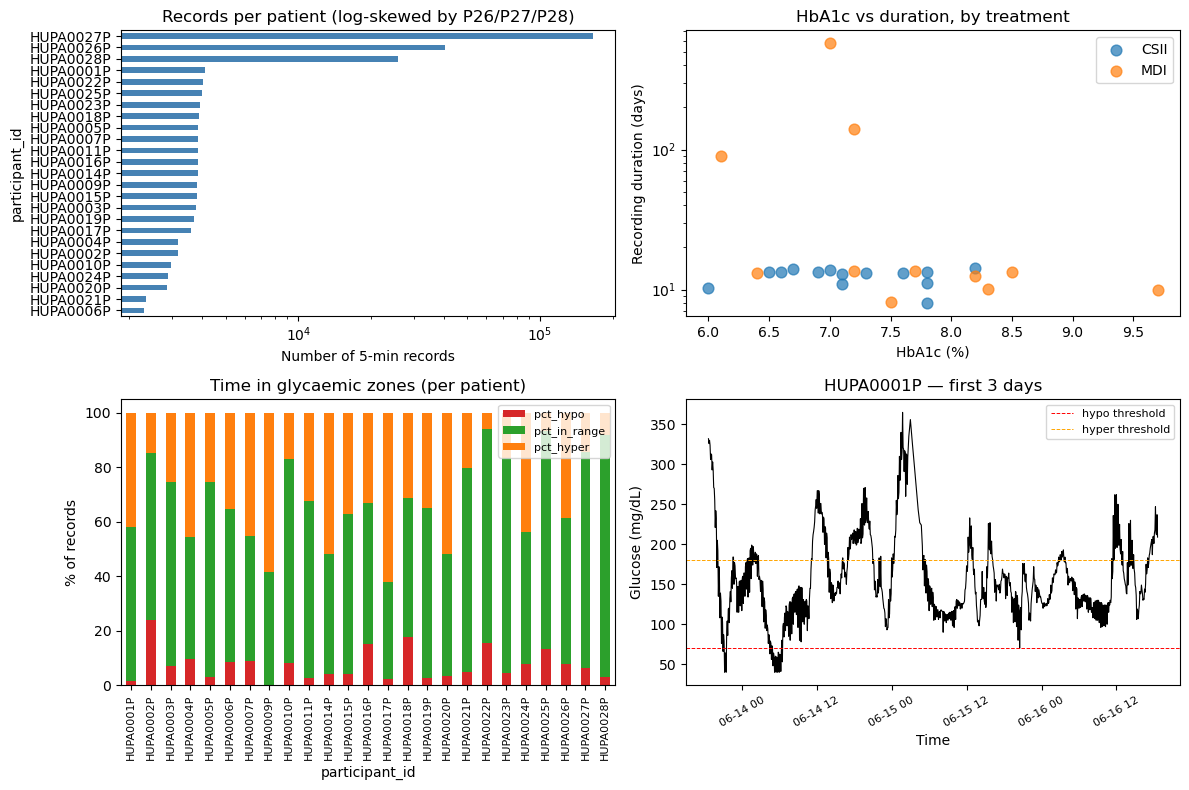

In [8]:
figures_dir = os.path.join(BASE_PATH, 'outputs', 'figures')
os.makedirs(figures_dir, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Per-patient row count
ax = axes[0, 0]
summary.sort_values('n_rows').plot.barh(
    x='participant_id', y='n_rows', ax=ax, legend=False, color='steelblue'
)
ax.set_xlabel('Number of 5-min records')
ax.set_title('Records per patient (log-skewed by P26/P27/P28)')
ax.set_xscale('log')

# 2) HbA1c distribution by treatment
ax = axes[0, 1]
for grp, sub in summary.groupby('treatment'):
    ax.scatter(sub['hba1c_pct'], sub['days'], label=grp, s=60, alpha=0.7)
ax.set_xlabel('HbA1c (%)')
ax.set_ylabel('Recording duration (days)')
ax.set_yscale('log')
ax.set_title('HbA1c vs duration, by treatment')
ax.legend()

# 3) Glycaemic zone distribution per patient
ax = axes[1, 0]
zone_df = summary.set_index('participant_id')[['pct_hypo','pct_in_range','pct_hyper']]
zone_df.plot.bar(stacked=True, ax=ax, color=['#d62728','#2ca02c','#ff7f0e'])
ax.set_ylabel('% of records')
ax.set_title('Time in glycaemic zones (per patient)')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.legend(loc='upper right', fontsize=8)

# 4) Sample glucose trace from HUPA0001P (first 3 days)
ax = axes[1, 1]
sample_pat = load_hupa_patient('HUPA0001P', BASE_PATH).iloc[:864]  # 3 days x 288
ax.plot(sample_pat['time'], sample_pat['glucose'], lw=0.8, color='black')
ax.axhline(70, color='red', ls='--', lw=0.7, label='hypo threshold')
ax.axhline(180, color='orange', ls='--', lw=0.7, label='hyper threshold')
ax.set_xlabel('Time')
ax.set_ylabel('Glucose (mg/dL)')
ax.set_title('HUPA0001P — first 3 days')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
out_png = os.path.join(figures_dir, '01_data_understanding_overview.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'Saved: {out_png}')
plt.show()

## Cell 8 — Completion summary

This notebook should be re-runnable end-to-end on a fresh Colab runtime with only the contents of `data/data_hupa/` mounted. If any cell raises an error, fix the cell rather than working around it; SKILL.md Rule 6 (Colab compatibility) is non-negotiable.

**Artefacts produced:**
- `data/interim/hupa_cohort_summary.csv`
- `outputs/figures/01_data_understanding_overview.png`

**Next step:** `notebooks/02_eda.ipynb` — Section 2 of SKILL.md (Meaningful EDA).